# AI & ML Task 2
## Feature Engineering, Model Optimization & Performance Comparison

### Objective
Build a House Price Prediction system using multiple Machine Learning models and compare their performance.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Required Libraries

In this step, we import all necessary Python libraries for:
- Data handling
- Visualization
- Machine Learning
- Model evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Load California Housing Dataset

The California Housing Dataset contains housing-related information such as:
- Median Income
- House Age
- Average Rooms
- Population

Target Variable:
- Median House Value

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['PRICE'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Dataset Exploration

In this section, we:
- Check dataset shape
- View column information
- Analyze statistical summary

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(20640, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900  

# Check Missing Values

Before training Machine Learning models, it is important to check whether the dataset contains missing values.

In [5]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


# Correlation Heatmap

A correlation heatmap helps us understand relationships between different features and the target variable.

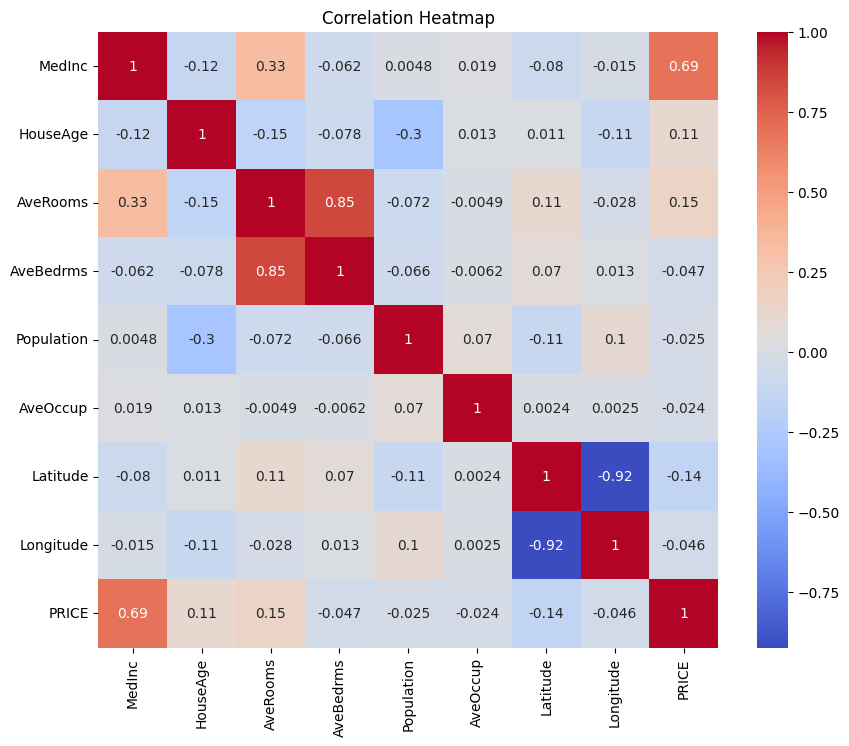

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Split Features and Target Variable

Features (X):
- Input variables used for prediction

Target (y):
- House Price

In [7]:
X = df.drop('PRICE', axis=1)

y = df['PRICE']

# Train-Test Split

The dataset is divided into:
- Training Data (80%)
- Testing Data (20%)

This helps evaluate model performance on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

Feature scaling standardizes the dataset so that all features contribute equally during model training.

Technique Used:
- StandardScaler

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Train Linear Regression Model

Linear Regression is a simple Machine Learning algorithm used for predicting continuous numerical values.

In [10]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

# Train Decision Tree Regressor

Decision Tree Regressor creates tree-based decision structures to improve prediction accuracy.

In [11]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

# Train Random Forest Regressor

Random Forest combines multiple decision trees to improve prediction performance and reduce overfitting.

In [12]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

# Model Evaluation Metrics

The following evaluation metrics are used:
- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [13]:
def evaluate_model(y_test, predictions):

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    return mae, mse, rmse, r2

# Evaluate All Models

In this section, we calculate evaluation metrics for:
- Linear Regression
- Decision Tree
- Random Forest

In [14]:
lr_results = evaluate_model(y_test, lr_pred)

dt_results = evaluate_model(y_test, dt_pred)

rf_results = evaluate_model(y_test, rf_pred)

# Model Performance Comparison

A comparison table helps identify the best-performing Machine Learning model.

In [15]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        lr_results[0],
        dt_results[0],
        rf_results[0]
    ],

    'MSE': [
        lr_results[1],
        dt_results[1],
        rf_results[1]
    ],

    'RMSE': [
        lr_results[2],
        dt_results[2],
        rf_results[2]
    ],

    'R2 Score': [
        lr_results[3],
        dt_results[3],
        rf_results[3]
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Decision Tree,0.453904,0.493969,0.702829,0.623042
2,Random Forest,0.327425,0.255170,0.505143,0.805275


# Identify Best Model

The best model is selected based on:
- Highest R² Score
- Lowest Error Values

In [16]:
best_model = results.sort_values(
    by='R2 Score',
    ascending=False
)

best_model

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,0.327425,0.255170,0.505143,0.805275
1,Decision Tree,0.453904,0.493969,0.702829,0.623042
0,Linear Regression,0.533200,0.555892,0.745581,0.575788


# Visualize Model Performance

A bar chart is used to compare the R² Scores of all models.

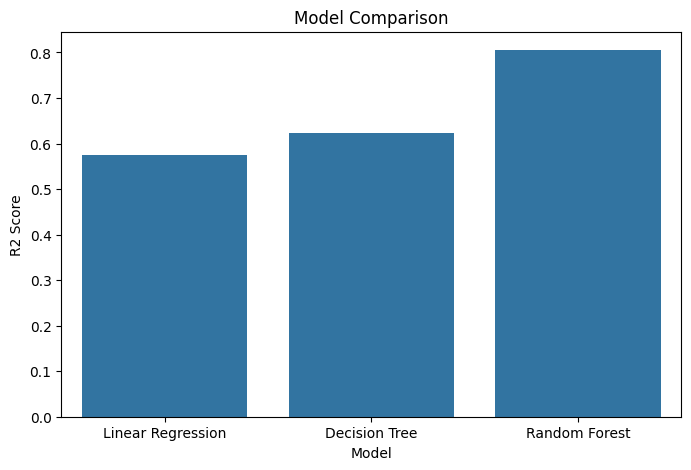

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")

plt.show()

# Save Best Performing Model

The best model is saved using Joblib for future use.

In [18]:
joblib.dump(rf, 'best_model.pkl')

['best_model.pkl']

# Conclusion

In this project, multiple Machine Learning regression models were trained and evaluated using the California Housing Dataset.

Feature scaling was applied to improve model performance and ensure fair learning across all features.

Among all models tested:
- Random Forest Regressor achieved the best performance
- It produced the highest R² Score
- It also generated lower prediction errors compared to other models

This project demonstrated a complete Machine Learning workflow including:
- Data preprocessing
- Feature scaling
- Model training
- Model evaluation
- Performance comparison
- Model selection

The project successfully fulfilled the objectives of Task 2.